In [1]:
import shap
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.utils.config import X_TRAIN_PATH,X_TEST_PATH,MODEL_PATH

c:\Users\USER\Desktop\Warfarin_IWPC_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = joblib.load(MODEL_PATH)

X_train = joblib.load(X_TRAIN_PATH)
X_test = joblib.load(X_TEST_PATH)

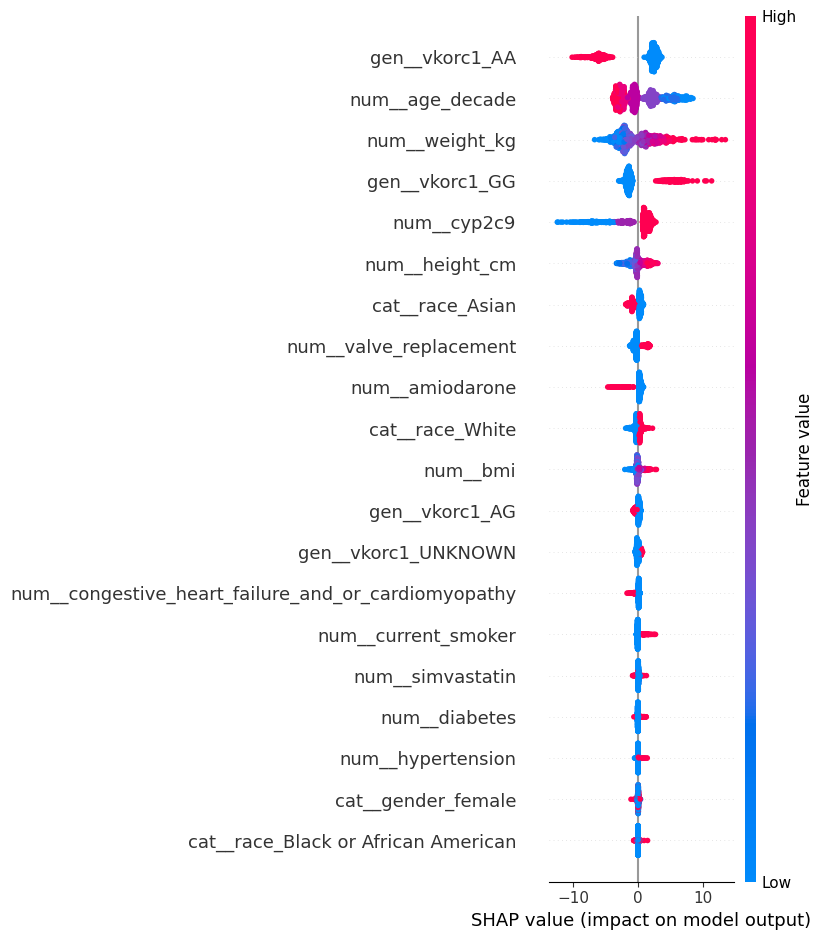

In [3]:

preprocessor = model.named_steps["preprocessor"]
xgb_model = model.named_steps["model"]


X_test=X_test.iloc[:1000]

X_test_transformed = preprocessor.transform(X_test)
X_test_transformed=X_test_transformed[:1000]
    
feature_names = preprocessor.get_feature_names_out()
 

explainer = shap.TreeExplainer(xgb_model,feature_perturbation="tree_path_dependent")

shap_values = explainer.shap_values(X_test_transformed)
X_plot=pd.DataFrame(X_test_transformed.toarray() if hasattr(X_test_transformed,"toarray") else X_test_transformed,columns=feature_names)
 
shap.summary_plot(
        shap_values,
        X_plot,
        max_display=20,
        show=False)

In [4]:
mean_absolute_shap=np.abs(shap_values).mean(axis=0)
global_importance=pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap' : mean_absolute_shap
}).sort_values('mean_abs_shap',ascending=False).head(20)
global_importance

,feature,mean_abs_shap
39,gen__vkorc1_AA,3.576324
11,num__age_decade,2.636231
1,num__weight_kg,2.512838
41,gen__vkorc1_GG,2.404756
13,num__cyp2c9,2.160341
0,num__height_cm,0.858782
32,cat__race_Asian,0.528377
4,num__valve_replacement,0.523635
14,num__amiodarone,0.412618
35,cat__race_White,0.378652


In [5]:
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)
shap_df

,num__height_cm,num__weight_kg,num__diabetes,num__congestive_heart_failure_and_or_cardiomyopathy,num__valve_replacement,num__aspirin,num__acetaminophen_or_paracetamol_tylenol,num__sulfonamide_antibiotics,num__macrolide_antibiotics,num__anti_fungal_azoles,...,cat__race_Black or African American,cat__race_Unknown,cat__race_White,cat__ethnicity_Hispanic or Latino,cat__ethnicity_Unknown,cat__ethnicity_not Hispanic or Latino,gen__vkorc1_AA,gen__vkorc1_AG,gen__vkorc1_GG,gen__vkorc1_UNKNOWN
0,1.392556,1.495221,-0.017455,0.053484,-0.305413,-0.003140,-0.020297,-0.000016,0.000269,0.000878,...,0.005247,0.007852,0.149943,-0.003121,-0.034447,0.098776,1.823969,-0.363058,-1.615358,-0.187753
1,-0.583299,-3.504906,-0.024754,0.082498,0.544508,0.003412,0.020986,0.000145,0.000233,0.001158,...,0.052522,-0.206389,-0.725192,-0.007034,-0.003978,0.024027,1.701174,0.122138,3.738404,0.064779
2,0.599142,-0.618062,-0.027675,0.097380,-0.288632,0.003208,-0.018527,0.000143,0.000233,0.000779,...,0.004324,-0.001872,0.233875,-0.002176,-0.006796,0.065203,2.331858,0.150980,-1.851864,0.290972
3,-0.201967,-2.680745,-0.077725,0.080642,-0.244214,0.001339,-0.042201,0.000073,0.000233,0.000508,...,-0.014592,-0.004333,0.164295,-0.011966,-0.057873,-0.004163,1.715946,0.209804,-1.325272,0.392118
4,1.546904,2.054755,0.027684,0.219917,-0.157902,0.063180,-0.007897,0.000242,0.000353,0.001916,...,0.204035,0.101650,0.895156,0.002364,0.033690,0.096656,3.313334,0.212636,5.908936,0.119261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.308519,-2.048703,-0.096485,-0.651298,-0.262530,0.010839,-0.030017,0.000251,0.000195,0.000687,...,-0.010075,0.007769,0.255402,-0.000747,0.127620,-0.037339,1.534185,-0.505258,-1.744537,-0.069946
996,2.136614,0.665144,-0.043068,0.059252,-0.175501,0.011051,-0.002877,-0.000019,0.000194,0.001196,...,0.029569,0.008862,0.228624,-0.003153,0.093290,0.036079,1.922222,0.188458,5.621275,0.060664
997,-0.075992,1.199503,-0.028514,0.074533,-0.308440,-0.012757,-0.015385,0.000199,0.000171,0.000834,...,0.000355,0.001599,0.158527,-0.000363,0.010858,-0.026830,2.071747,-0.386934,-1.324414,-0.219308
998,0.504605,5.384549,0.128001,0.097169,-0.177494,0.005107,-0.002680,0.000509,0.002709,0.003170,...,-0.225000,0.051141,0.229519,-0.000277,-0.633335,-0.055124,2.141131,-0.341636,-1.969947,-0.034390


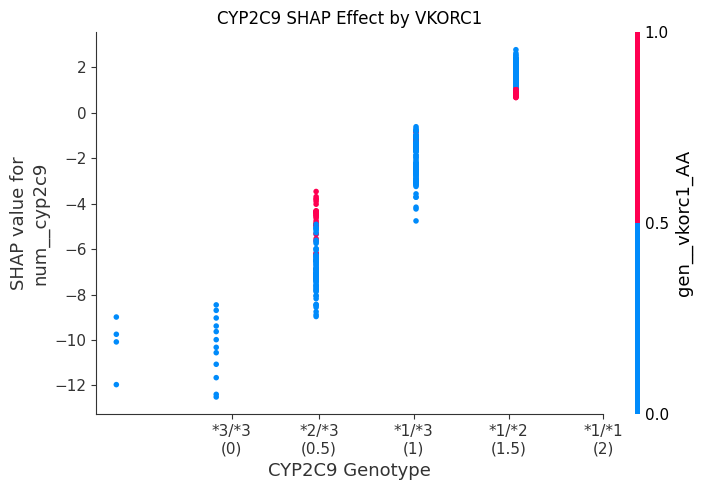

In [6]:

cyp2c9_col = [f for f in feature_names if 'cyp2c9' in f][0]
vkorc1_col = [f for f in feature_names if 'vkorc1' in f][0]

shap.dependence_plot(
    ind=cyp2c9_col,
    shap_values=shap_values, 
    features=X_plot,
    feature_names=feature_names,
    interaction_index=vkorc1_col, 
    show=False
)
plt.xticks([-3.4, -2.2, -0.9, 0.4, 1.7],
           ['*3/*3\n(0)', '*2/*3\n(0.5)', '*1/*3\n(1)', '*1/*2\n(1.5)', '*1/*1\n(2)'])
plt.xlabel("CYP2C9 Genotype")
plt.title("CYP2C9 SHAP Effect by VKORC1")
plt.tight_layout()
plt.savefig("cyp2c9_vs_vkorc1.png", dpi=300)
plt.show()


In [7]:
mask = (
    (X_test["vkorc1"] == "AA") &
    (X_test["cyp2c9"] == 0.0) )
cyp_col=[col for col in feature_names if "cyp2c9" in col]
vkorc1_col=[col for col in feature_names if "vkorc1" in col]
relevant_cols=cyp_col + vkorc1_col

interaction = shap_df.loc[mask,relevant_cols].sum(axis=1).mean()
interaction


nan

In [8]:
mask = (
    (X_test["vkorc1"] == "AA") &
    (X_test["age_decade"] > 8.0) &
      (X_test["amiodarone"] == 1)  )
cyp_col=[col for col in feature_names if "cyp2c9" in col]
vkorc1_col=[col for col in feature_names if "vkorc1" in col]
amiodarone_col=[col for col in feature_names if "vkorc1" in col]
relevant_cols=cyp_col + vkorc1_col + amiodarone_col

interaction = shap_df.loc[mask,relevant_cols].sum(axis=1).mean()
interaction

nan

In [ ]:
mask = (
    (X_test["cyp2c9"] == 0.0) &
    (X_test["age_decade"] > 8.0) &
      (X_test["amiodarone"] == 1)  )
cyp_col=[col for col in feature_names if "cyp2c9" in col]
vkorc1_col=[col for col in feature_names if "vkorc1" in col]
amiodarone_col=[col for col in feature_names if "vkorc1" in col]
relevant_cols=cyp_col + vkorc1_col + amiodarone_col

interaction = shap_df.loc[mask,relevant_cols].sum(axis=1).mean()
interaction

nan

: 

In [9]:
mask = X_test["vkorc1"] == "UNKNOWN"
vkorc1_unknown__col=[col for col in feature_names if "UNKNOWN" in col]
effect = shap_df.loc[mask, vkorc1_unknown__col].mean()

print("UNKNOWN VKORC1 GENOTYPE EFFECT:", effect)

UNKNOWN VKORC1 GENOTYPE EFFECT: gen__vkorc1_UNKNOWN    0.340698
dtype: float32


In [10]:
mask_aa = X_test["vkorc1"] == "AA"
mask_ga = X_test["vkorc1"] == "AG"
mask_gg = X_test["vkorc1"] == "GG"

vkorc1_aa_col = [col for col in feature_names if "vkorc1" in col and "AA" in col][0]
vkorc1_ag_col = [col for col in feature_names if "vkorc1" in col and "AG" in col][0]
vkorc1_gg_col = [col for col in feature_names if "vkorc1" in col and "GG" in col][0]

print("VKORC1 AA:", shap_df.loc[mask_aa, vkorc1_aa_col].mean())
print("VKORC1 AG:", shap_df.loc[mask_ga, vkorc1_ag_col].mean())
print("VKORC1 GG:", shap_df.loc[mask_gg, vkorc1_gg_col].mean())

VKORC1 AA: -6.212993
VKORC1 AG: -0.45533574
VKORC1 GG: 5.535849


In [11]:
for genotype in sorted(X_test["cyp2c9"].unique()):
    mask = X_test["cyp2c9"] == genotype
    cyp2c9_col=[col for col in feature_names if "cyp2c9" in col]
    effect = shap_df.loc[mask, cyp2c9_col].values.mean()
    print(f"Genotype{genotype}: {effect:.6f}")

Genotype0.0: -10.195353
Genotype0.5: -10.306315
Genotype1.0: -6.294283
Genotype1.5: -1.990867
Genotype2.0: 1.379388


#cyp2c9 genotypes mapping:
   
     '*1/*1' : 2.0
     '*1/*2' : 1.5
     '*1/*3' : 1.0
     '*2/*2' : 1.0
     '*2/*3' : 0.5
     '*3/*3' : 0.0

In [12]:
mask = X_test["amiodarone"] == 1
amiodarone_col=[col for col in feature_names if "amiodarone" in col]
effect = shap_df.loc[mask, amiodarone_col].mean()

print("Amiodarone effect:", effect)

Amiodarone effect: num__amiodarone   -2.613659
dtype: float32


In [13]:
mask = (
    (X_test["vkorc1"] == "AA") &
    (X_test["amiodarone"] == 1) 
   
)
amiodarone_col=[col for col in feature_names if "amiodarone" in col]
vkorc1_col=[col for col in feature_names if "vkorc1" in col]
relevant_cols=amiodarone_col + vkorc1_col

interaction = shap_df.loc[mask,relevant_cols].sum(axis=1).mean()

print("AA + amiodarone total contribution:", interaction)

AA + amiodarone total contribution: -7.9718533


- VKORC1 AA significantly reduces dose → increased sensitivity
- CYP2C9 variants reduce metabolism → lower dose required
- Amiodarone further decreases dose via drug interaction

Clinical validation:
- Matches pharmacogenetic expectations (CPIC guidelines)
- Model captures biologically meaningful relationships
Limitations:
-  Model assumes UNKNOWN VKORC1 patients need higher doses

